<a href="https://colab.research.google.com/github/handeunaldi/dsa-210-project/blob/main/eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis – GDP, Healthcare Expenditure, and Life Expectancy

This notebook presents the main exploratory data analysis (EDA) and hypothesis testing for the project:

> **Economic Development and Health Outcomes: GDP, Healthcare Spending, and Life Expectancy**

The goal is to examine how GDP per capita and healthcare expenditure per capita are associated with life expectancy across countries.

The notebook is organised as follows:

1. **Setup and data loading**  
2. **Data cleaning and preparation**  
3. **Descriptive statistics and sanity checks**  
4. **Exploratory data analysis (EDA)**  
5. **Hypothesis testing**  
6. **Regression analysis**  
7. **Conclusion**

All plots use consistent formatting and readable labels so that they can be exported directly into the report.

In [32]:
# ============================================================
# 1. Setup and data loading
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, ttest_ind, spearmanr
import statsmodels.api as sm
from pathlib import Path

# Plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

# Optional figure folder
PROJECT_ROOT = Path("/content")
FIG_DIR = PROJECT_ROOT / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Load datasets
life = pd.read_csv("/content/life-expectancy.csv")
health = pd.read_csv("/content/annual-healthcare-expenditure-per-capita.csv")
gdp = pd.read_csv("/content/gdp-per-capita-worldbank.csv")

print("Life expectancy shape:", life.shape)
print("Health expenditure shape:", health.shape)
print("GDP shape:", gdp.shape)

display(life.head())
display(health.head())
display(gdp.head())

Life expectancy shape: (21565, 4)
Health expenditure shape: (4869, 4)
GDP shape: (7240, 5)


,Entity,Code,Year,Life expectancy
0,Afghanistan,AFG,1950,28.1563
1,Afghanistan,AFG,1951,28.5836
2,Afghanistan,AFG,1952,29.0138
3,Afghanistan,AFG,1953,29.4521
4,Afghanistan,AFG,1954,29.6975


,Entity,Code,Year,"Current health expenditure per capita, PPP (current international $)"
0,Afghanistan,AFG,2002,85.857500
1,Afghanistan,AFG,2003,85.933020
2,Afghanistan,AFG,2004,93.935810
3,Afghanistan,AFG,2005,105.927704
4,Afghanistan,AFG,2006,118.405820


,Entity,Code,Year,GDP per capita,World region according to OWID
0,Afghanistan,AFG,2000,1617.8264,Asia
1,Afghanistan,AFG,2001,1454.1108,Asia
2,Afghanistan,AFG,2002,1774.3087,Asia
3,Afghanistan,AFG,2003,1815.9282,Asia
4,Afghanistan,AFG,2004,1776.9182,Asia


## 2. Data cleaning and preparation

In this section, the three datasets are cleaned and standardised. Column names are renamed for readability, only the relevant variables are kept, and the datasets are merged using country, country code, and year.

The sample is restricted to years where all three datasets overlap.

In [33]:
# ============================================================
# 2. Data cleaning and preparation
# ============================================================

# Rename columns
life = life.rename(columns={
    "Entity": "Country",
    "Code": "Code",
    "Year": "Year",
    "Life expectancy": "LifeExpectancy"
})

health = health.rename(columns={
    "Entity": "Country",
    "Code": "Code",
    "Year": "Year",
    "Current health expenditure per capita, PPP (current international $)": "HealthExpPerCapita"
})

gdp = gdp.rename(columns={
    "Entity": "Country",
    "Code": "Code",
    "Year": "Year",
    "GDP per capita": "GDPPerCapita",
    "World region according to OWID": "Region"
})

# Keep only needed columns
life = life[["Country", "Code", "Year", "LifeExpectancy"]]
health = health[["Country", "Code", "Year", "HealthExpPerCapita"]]
gdp = gdp[["Country", "Code", "Year", "GDPPerCapita", "Region"]]

# Merge datasets
df = life.merge(gdp, on=["Country", "Code", "Year"], how="inner")
df = df.merge(health, on=["Country", "Code", "Year"], how="inner")

# Keep valid country codes only
df = df[df["Code"].notna()]
df = df[df["Code"].str.len() == 3]

# Convert numeric columns
numeric_cols = ["LifeExpectancy", "GDPPerCapita", "HealthExpPerCapita"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Drop missing values
df = df.dropna(subset=numeric_cols)

# Restrict years to overlap period
df = df[df["Year"] >= 2002]

print("Final merged shape:", df.shape)
display(df.head())

Final merged shape: (4043, 7)


,Country,Code,Year,LifeExpectancy,GDPPerCapita,Region,HealthExpPerCapita
0,Afghanistan,AFG,2002,56.2251,1774.3087,Asia,85.857500
1,Afghanistan,AFG,2003,57.1713,1815.9282,Asia,85.933020
2,Afghanistan,AFG,2004,57.8098,1776.9182,Asia,93.935810
3,Afghanistan,AFG,2005,58.2468,1908.1147,Asia,105.927704
4,Afghanistan,AFG,2006,58.5533,1929.7239,Asia,118.405820


## 3. Descriptive statistics and sanity checks

Before moving to the visual analysis, we check the basic structure of the final merged dataset:

- number of observations  
- number of unique countries  
- year range  
- missing values  
- summary statistics  

This helps confirm that the merge and cleaning steps worked correctly.

In [35]:
# ============================================================
# 3. Descriptive statistics and sanity checks
# ============================================================

print("Number of observations:", len(df))
print("Number of unique countries:", df["Country"].nunique())
print("Year range:", df["Year"].min(), "-", df["Year"].max())

print("\nMissing values by column:")
print(df.isnull().sum())

print("\nSummary statistics:")
display(df[["Year", "LifeExpectancy", "GDPPerCapita", "HealthExpPerCapita"]].describe())

Number of observations: 4043
Number of unique countries: 186
Year range: 2002 - 2023

Missing values by column:
Country               0
Code                  0
Year                  0
LifeExpectancy        0
GDPPerCapita          0
Region                0
HealthExpPerCapita    0
dtype: int64

Summary statistics:


,Year,LifeExpectancy,GDPPerCapita,HealthExpPerCapita
count,4043.000000,4043.000000,4043.000000,4043.000000
mean,2012.545387,70.456136,22179.608461,1285.137700
std,6.331445,8.559314,23715.462384,1668.930732
min,2002.000000,14.665500,795.772160,10.528234
25%,2007.000000,64.926500,4969.267100,188.068770
50%,2013.000000,71.706900,13586.516000,615.814450
75%,2018.000000,76.776000,31498.880500,1662.828650
max,2023.000000,85.708200,145590.770000,13473.193000


## 4. Exploratory Data Analysis (EDA)

This section explores the relationships between GDP per capita, healthcare expenditure, and life expectancy through visual analysis.

The goal is not to formally test the hypotheses yet, but to build intuition by examining patterns in the data.

The hypotheses are explored visually as follows:

- **H1:** GDP per capita is associated with healthcare expenditure  
- **H2:** GDP per capita is associated with life expectancy  
- **H3:** Healthcare expenditure is associated with life expectancy  

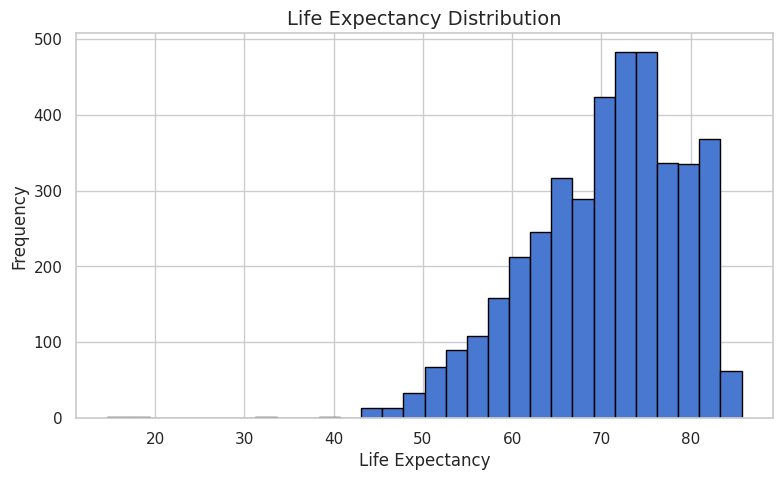

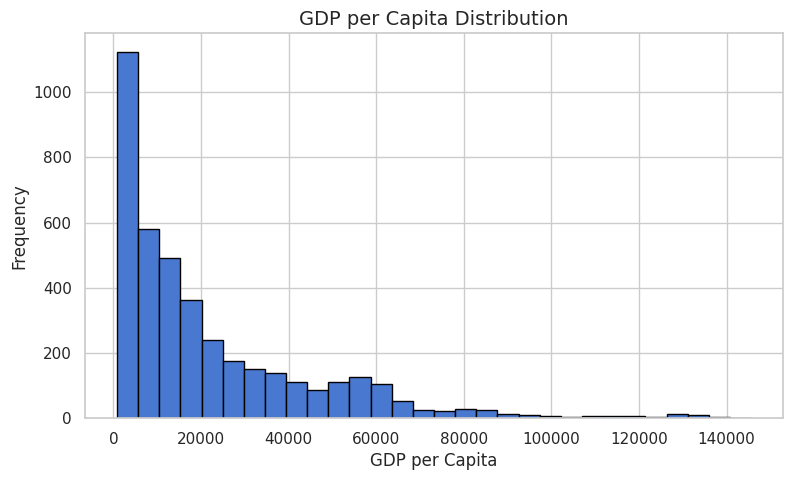

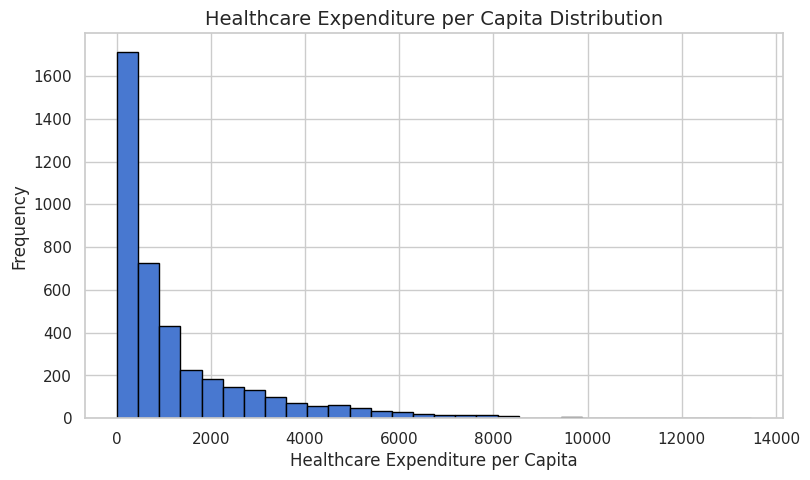

In [36]:
# ============================================================
# 4.1 Distributions
# ============================================================

plt.hist(df["LifeExpectancy"], bins=30, edgecolor="black")
plt.title("Life Expectancy Distribution")
plt.xlabel("Life Expectancy")
plt.ylabel("Frequency")
plt.savefig(FIG_DIR / "life_expectancy_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

plt.hist(df["GDPPerCapita"], bins=30, edgecolor="black")
plt.title("GDP per Capita Distribution")
plt.xlabel("GDP per Capita")
plt.ylabel("Frequency")
plt.savefig(FIG_DIR / "gdp_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

plt.hist(df["HealthExpPerCapita"], bins=30, edgecolor="black")
plt.title("Healthcare Expenditure per Capita Distribution")
plt.xlabel("Healthcare Expenditure per Capita")
plt.ylabel("Frequency")
plt.savefig(FIG_DIR / "health_exp_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### Insight

Life expectancy appears more concentrated within a narrower range, while GDP per capita and healthcare expenditure per capita are heavily right-skewed. This indicates that a relatively small number of countries have very high income and health spending levels.

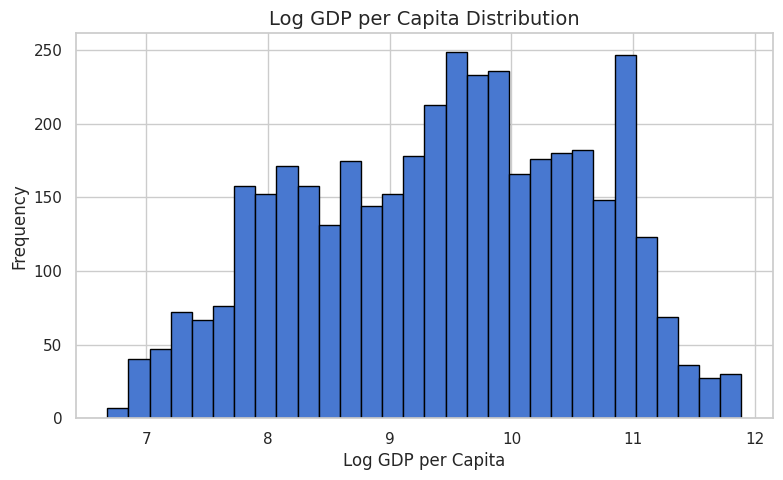

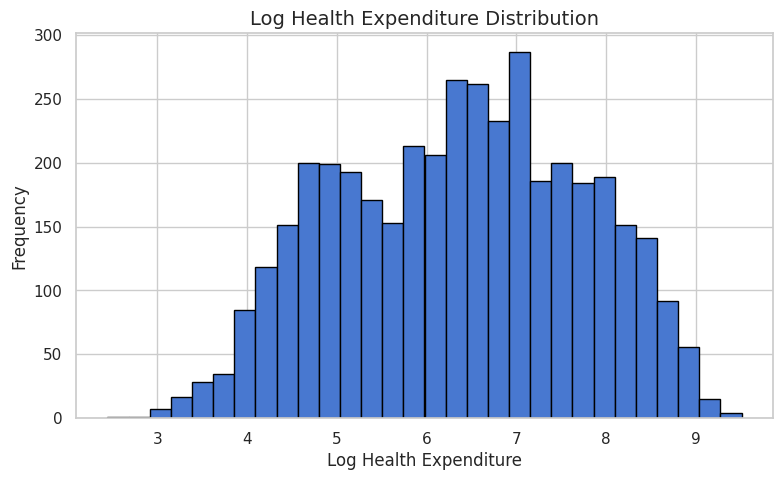

In [37]:
# ============================================================
# 4.2 Log transformation
# ============================================================

df["LogGDP"] = np.log(df["GDPPerCapita"] + 1)
df["LogHealth"] = np.log(df["HealthExpPerCapita"] + 1)

plt.hist(df["LogGDP"], bins=30, edgecolor="black")
plt.title("Log GDP per Capita Distribution")
plt.xlabel("Log GDP per Capita")
plt.ylabel("Frequency")
plt.savefig(FIG_DIR / "log_gdp_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

plt.hist(df["LogHealth"], bins=30, edgecolor="black")
plt.title("Log Health Expenditure Distribution")
plt.xlabel("Log Health Expenditure")
plt.ylabel("Frequency")
plt.savefig(FIG_DIR / "log_health_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### Insight

Log transformations reduce skewness in GDP and healthcare expenditure, making the variables more suitable for correlation analysis, scatter plots, and regression models.

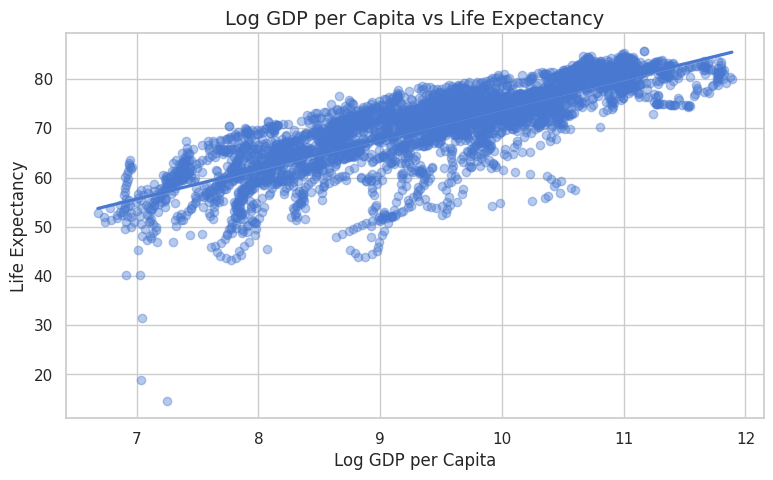

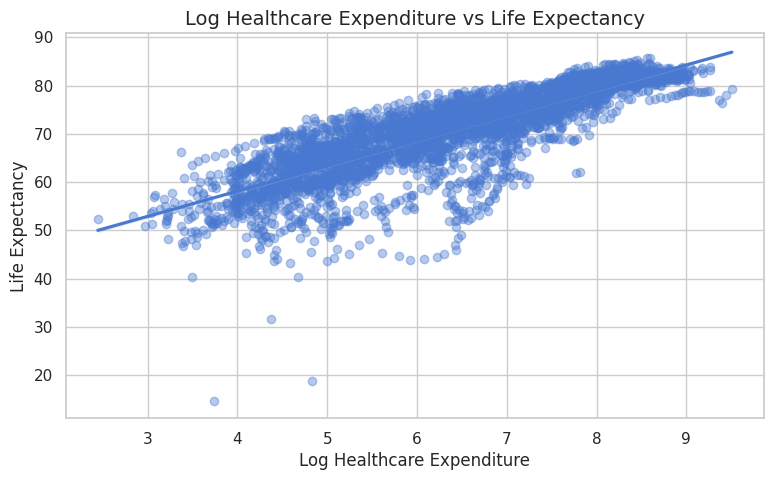

In [38]:
# ============================================================
# 4.3 Scatter plots
# ============================================================

sns.regplot(data=df, x="LogGDP", y="LifeExpectancy", scatter_kws={"alpha": 0.4})
plt.title("Log GDP per Capita vs Life Expectancy")
plt.xlabel("Log GDP per Capita")
plt.ylabel("Life Expectancy")
plt.savefig(FIG_DIR / "log_gdp_vs_life.png", dpi=300, bbox_inches="tight")
plt.show()

sns.regplot(data=df, x="LogHealth", y="LifeExpectancy", scatter_kws={"alpha": 0.4})
plt.title("Log Healthcare Expenditure vs Life Expectancy")
plt.xlabel("Log Healthcare Expenditure")
plt.ylabel("Life Expectancy")
plt.savefig(FIG_DIR / "log_health_vs_life.png", dpi=300, bbox_inches="tight")
plt.show()

### Insight

Both scatter plots suggest a clear positive relationship: countries with higher GDP per capita and higher healthcare expenditure tend to have longer life expectancy.

### Insight

Life expectancy is strongly positively correlated with both log GDP per capita and log healthcare expenditure. At the same time, GDP and healthcare expenditure are also highly correlated with each other, suggesting possible multicollinearity in multiple regression models.

,LifeExpectancy,GDPPerCapita,HealthExpPerCapita
Region,,,
Europe,78.129604,44161.853881,2985.153114
South America,73.056524,17536.560613,1025.630278
North America,73.012870,21152.656500,1376.331304
Asia,72.606770,24072.058546,975.253836
Oceania,68.881048,12387.267008,950.109308
Africa,60.978971,6579.126218,271.245127


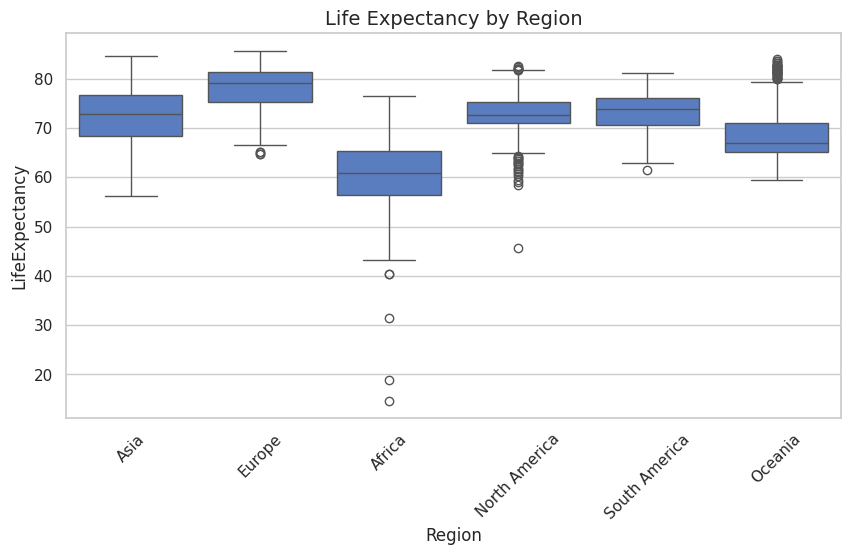

In [40]:
# ============================================================
# 4.5 Regional comparison
# ============================================================

region_summary = (
    df.groupby("Region")[["LifeExpectancy", "GDPPerCapita", "HealthExpPerCapita"]]
    .mean()
    .sort_values("LifeExpectancy", ascending=False)
)

display(region_summary)

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="Region", y="LifeExpectancy")
plt.xticks(rotation=45)
plt.title("Life Expectancy by Region")
plt.savefig(FIG_DIR / "life_expectancy_by_region.png", dpi=300, bbox_inches="tight")
plt.show()

### H1: GDP per capita and healthcare expenditure

We expect countries with higher GDP per capita to spend more on healthcare. This relationship reflects the idea that wealthier countries have more resources to invest in public health systems.

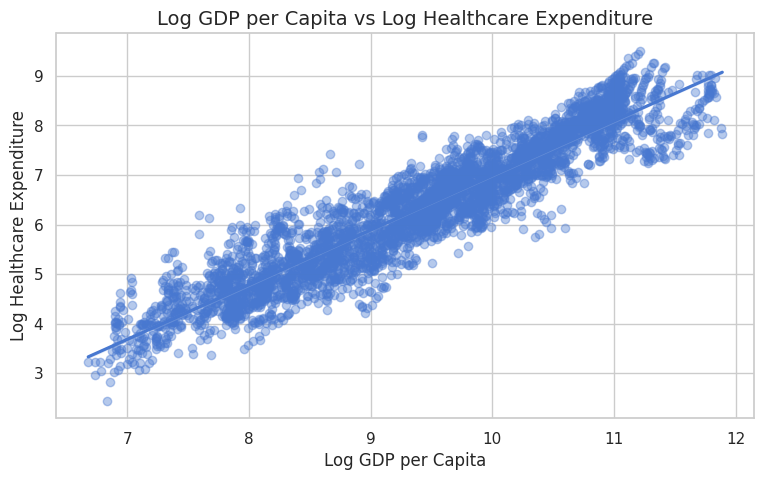

In [42]:
sns.regplot(data=df, x="LogGDP", y="LogHealth", scatter_kws={"alpha":0.4})

plt.title("Log GDP per Capita vs Log Healthcare Expenditure")
plt.xlabel("Log GDP per Capita")
plt.ylabel("Log Healthcare Expenditure")

plt.savefig(FIG_DIR / "h1_gdp_vs_health.png", dpi=300, bbox_inches="tight")
plt.show()

**Insight:**  
The plot shows a strong positive relationship between GDP and healthcare expenditure. Countries with higher income levels tend to allocate more resources to healthcare.

### H2: GDP per capita and life expectancy

Economic theory suggests that higher income levels improve living conditions, nutrition, and access to healthcare, which in turn increase life expectancy.

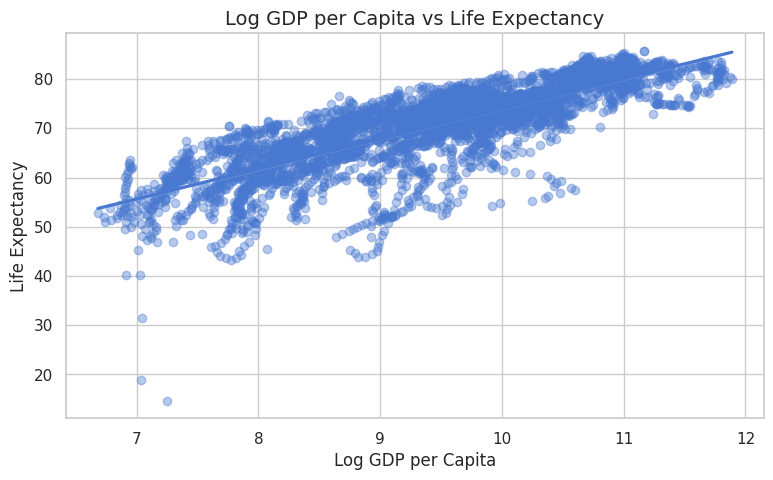

In [43]:
sns.regplot(data=df, x="LogGDP", y="LifeExpectancy", scatter_kws={"alpha":0.4})

plt.title("Log GDP per Capita vs Life Expectancy")
plt.xlabel("Log GDP per Capita")
plt.ylabel("Life Expectancy")

plt.savefig(FIG_DIR / "h2_gdp_vs_life.png", dpi=300, bbox_inches="tight")
plt.show()

**Insight:**  
There is a clear upward trend, indicating that countries with higher GDP per capita tend to have longer life expectancy.

### H3: Healthcare expenditure and life expectancy

Higher healthcare spending is expected to improve health outcomes by increasing access to medical services and improving quality of care.

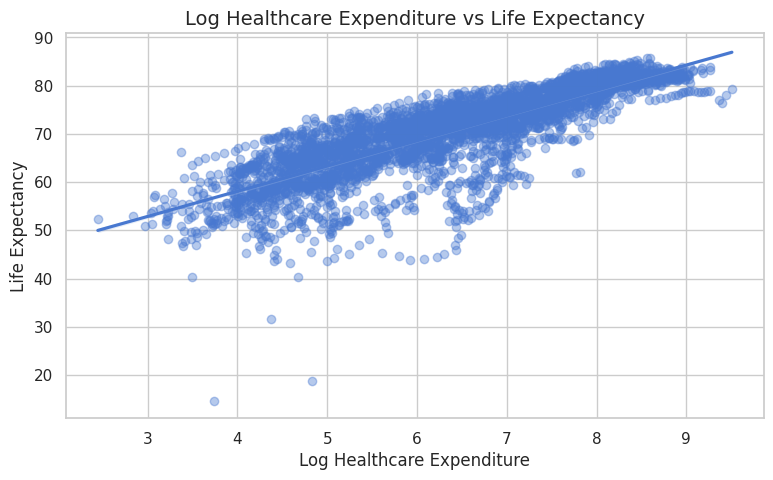

In [44]:
sns.regplot(data=df, x="LogHealth", y="LifeExpectancy", scatter_kws={"alpha":0.4})

plt.title("Log Healthcare Expenditure vs Life Expectancy")
plt.xlabel("Log Healthcare Expenditure")
plt.ylabel("Life Expectancy")

plt.savefig(FIG_DIR / "h3_health_vs_life.png", dpi=300, bbox_inches="tight")
plt.show()

**Insight:**  
The relationship appears strongly positive, suggesting that higher healthcare investment is associated with longer life expectancy.

,LifeExpectancy,LogGDP,LogHealth
LifeExpectancy,1.000000,0.823381,0.831385
LogGDP,0.823381,1.000000,0.937367
LogHealth,0.831385,0.937367,1.000000


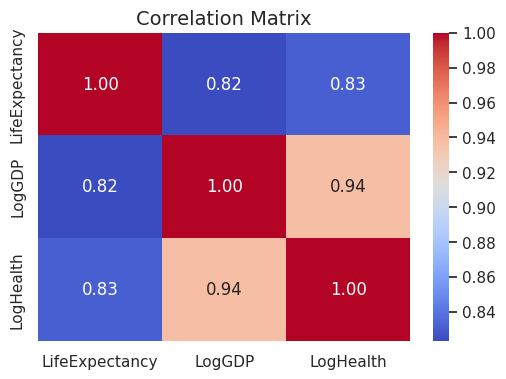

In [39]:
# ============================================================
# 4.4 Correlation matrix
# ============================================================

corr = df[["LifeExpectancy", "LogGDP", "LogHealth"]].corr()
display(corr)

plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.savefig(FIG_DIR / "correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()